# import needded columns

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,classification_report,mean_squared_error

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint



## **Data Representation**

In [198]:
df=pd.read_csv('D:\\PROJECTS\\PROJECT 39\\mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [199]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [200]:
df.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [201]:
df.sample()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
425,e,x,s,w,t,a,f,w,n,n,...,s,w,w,p,w,o,p,n,v,d


In [202]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [203]:
df.index

RangeIndex(start=0, stop=8124, step=1)

In [204]:
df.value_counts()

class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  gill-spacing  gill-size  gill-color  stalk-shape  stalk-root  stalk-surface-above-ring  stalk-surface-below-ring  stalk-color-above-ring  stalk-color-below-ring  veil-type  veil-color  ring-number  ring-type  spore-print-color  population  habitat
p      x          y            y          f        n     f                c             n          w           e            ?           k                         y                         w                       y                       p          w           o            e          w                  v           d          1
e      b          f            g          f        n     f                w             b          g           e            ?           k                         k                         w                       w                       p          w           t            p          w                  n           g          1
                        

In [205]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [206]:
df.values

array([['p', 'x', 's', ..., 'k', 's', 'u'],
       ['e', 'x', 's', ..., 'n', 'n', 'g'],
       ['e', 'b', 's', ..., 'n', 'n', 'm'],
       ...,
       ['e', 'f', 's', ..., 'b', 'c', 'l'],
       ['p', 'k', 'y', ..., 'w', 'v', 'l'],
       ['e', 'x', 's', ..., 'o', 'c', 'l']],
      shape=(8124, 23), dtype=object)

In [207]:
df.shape

(8124, 23)

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

## **Data Wrangling**

**Missing Values**

In [209]:
df.isna().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

**DUPLICATED Values**

In [210]:
df.duplicated().sum()

np.int64(0)

In [211]:
df[df.duplicated()]


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat


In [212]:
df[df.duplicated(keep=False)]

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat


## **Exploratory Data Analysis**

#### **Univariate Analysis**

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [214]:
df['habitat'].value_counts()

habitat
d    3148
g    2148
p    1144
l     832
u     368
m     292
w     192
Name: count, dtype: int64

In [215]:
df['population'].value_counts()

population
v    4040
y    1712
s    1248
n     400
a     384
c     340
Name: count, dtype: int64

In [216]:
df['ring-type'].value_counts()

ring-type
p    3968
e    2776
l    1296
f      48
n      36
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\4290794330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['ring-type'].value_counts().index,y=df['ring-type'].value_counts().values , palette='Set1',width=0.2)


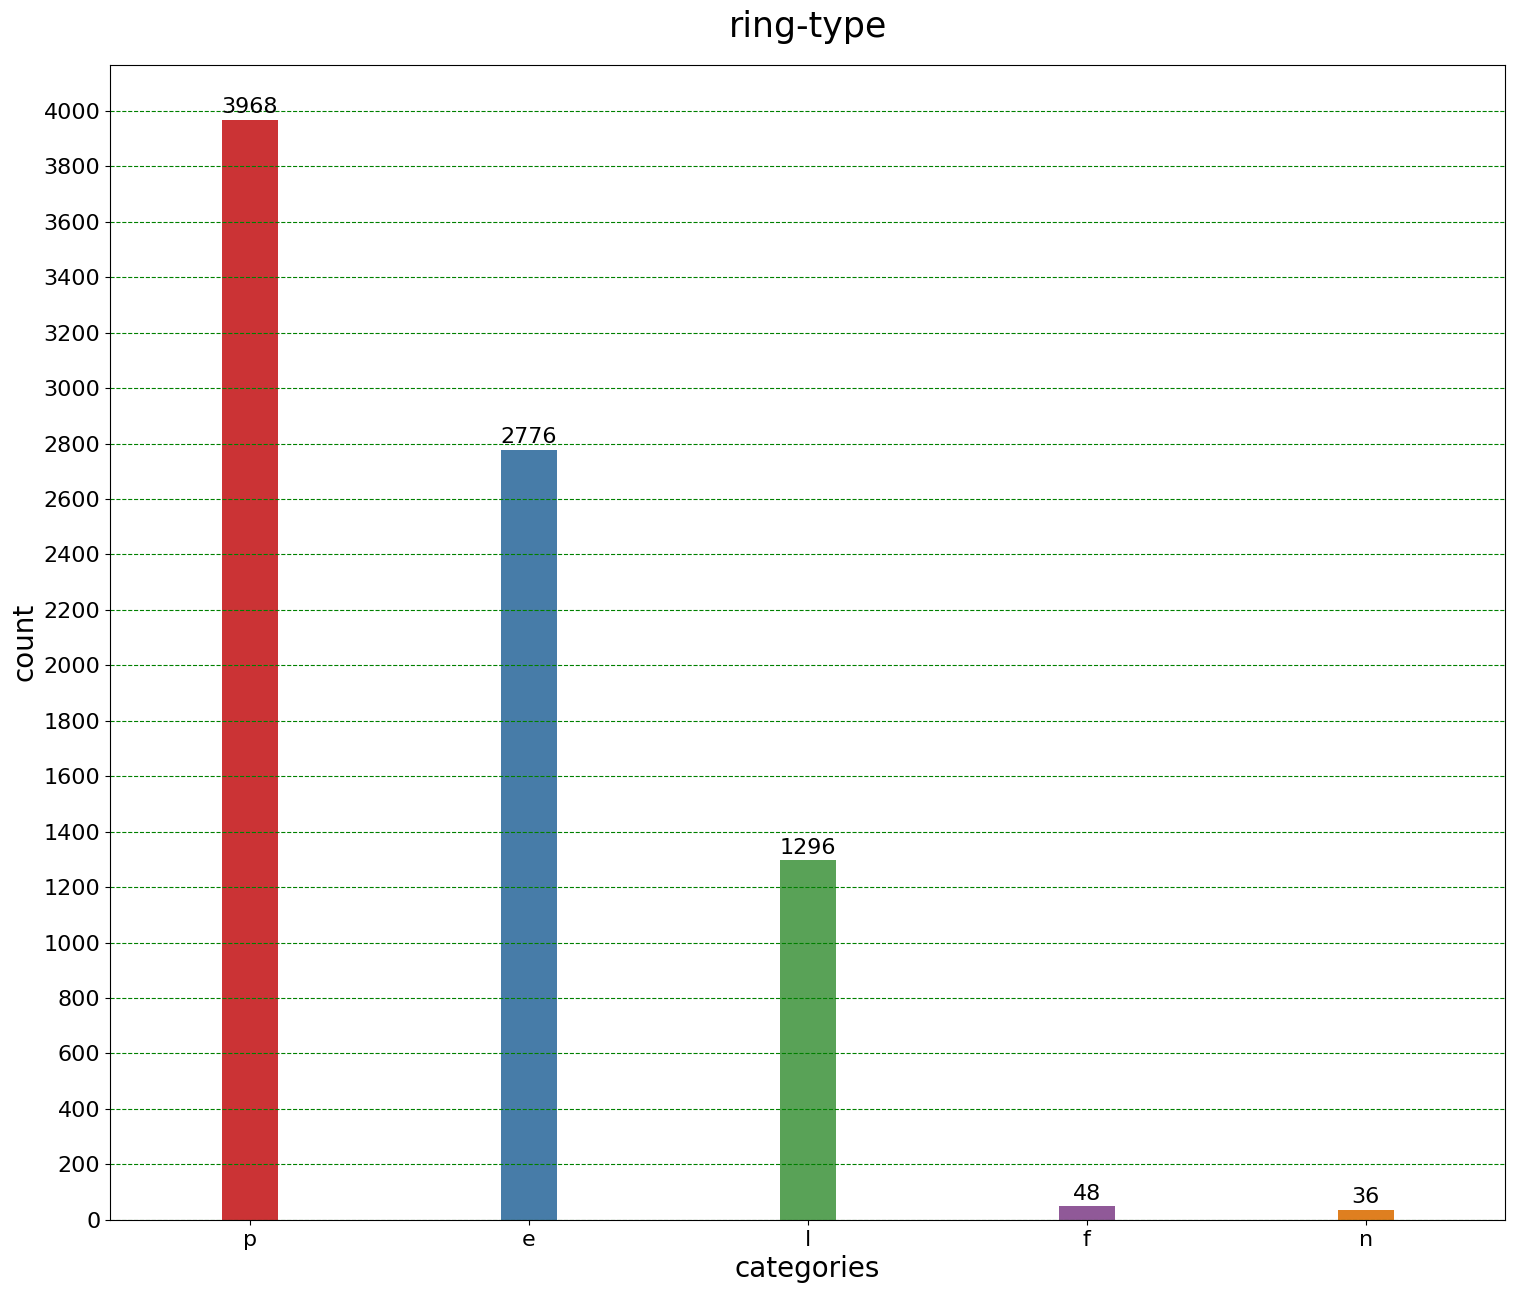

In [217]:
plt.figure(figsize=(18,15))
ax = sns.barplot(x=df['ring-type'].value_counts().index,y=df['ring-type'].value_counts().values , palette='Set1',width=0.2)
plt.title('ring-type',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,4200,200),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)

plt.show()


In [218]:
df['ring-number'].value_counts()

ring-number
o    7488
t     600
n      36
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\676377871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='ring-number', data=df, palette='Set2',width=0.2)


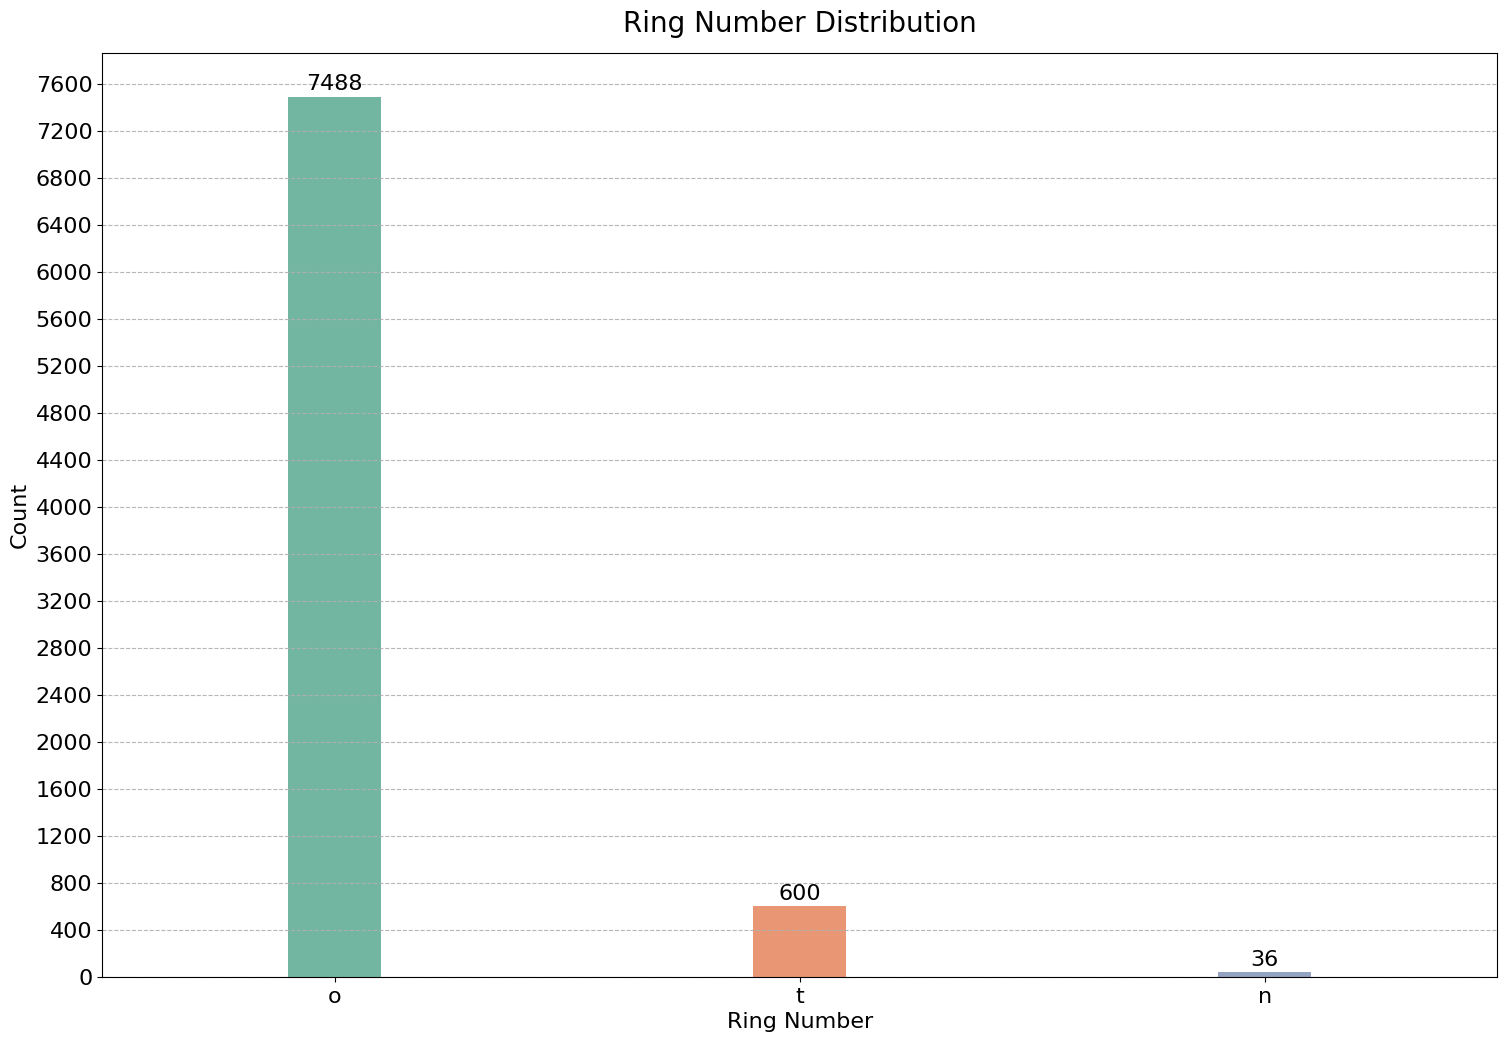

In [219]:
plt.figure(figsize=(18,12))
ax=sns.countplot(x='ring-number', data=df, palette='Set2',width=0.2) 
plt.title('Ring Number Distribution', fontsize=20, pad=15)
plt.xlabel('Ring Number', fontsize=16) 
plt.ylabel('Count', fontsize=16) 
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.xticks(fontsize=16)
plt.yticks(range(0,8000,400),fontsize=16)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)
plt.show()

In [220]:
df['veil-type'].value_counts()

veil-type
p    8124
Name: count, dtype: int64

In [221]:
df['stalk-color-below-ring'].value_counts()

stalk-color-below-ring
w    4384
p    1872
g     576
n     512
b     432
o     192
e      96
c      36
y      24
Name: count, dtype: int64

In [222]:
df['stalk-color-above-ring'].value_counts()

stalk-color-above-ring
w    4464
p    1872
g     576
n     448
b     432
o     192
e      96
c      36
y       8
Name: count, dtype: int64

In [223]:
df['stalk-surface-above-ring'].value_counts()

stalk-surface-above-ring
s    5176
k    2372
f     552
y      24
Name: count, dtype: int64

In [224]:
df['stalk-root'].value_counts()

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [225]:
df['stalk-shape'].value_counts()

stalk-shape
t    4608
e    3516
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\793337802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['stalk-shape'].value_counts().index,y=df['stalk-shape'].value_counts().values , palette='muted',width=0.1)


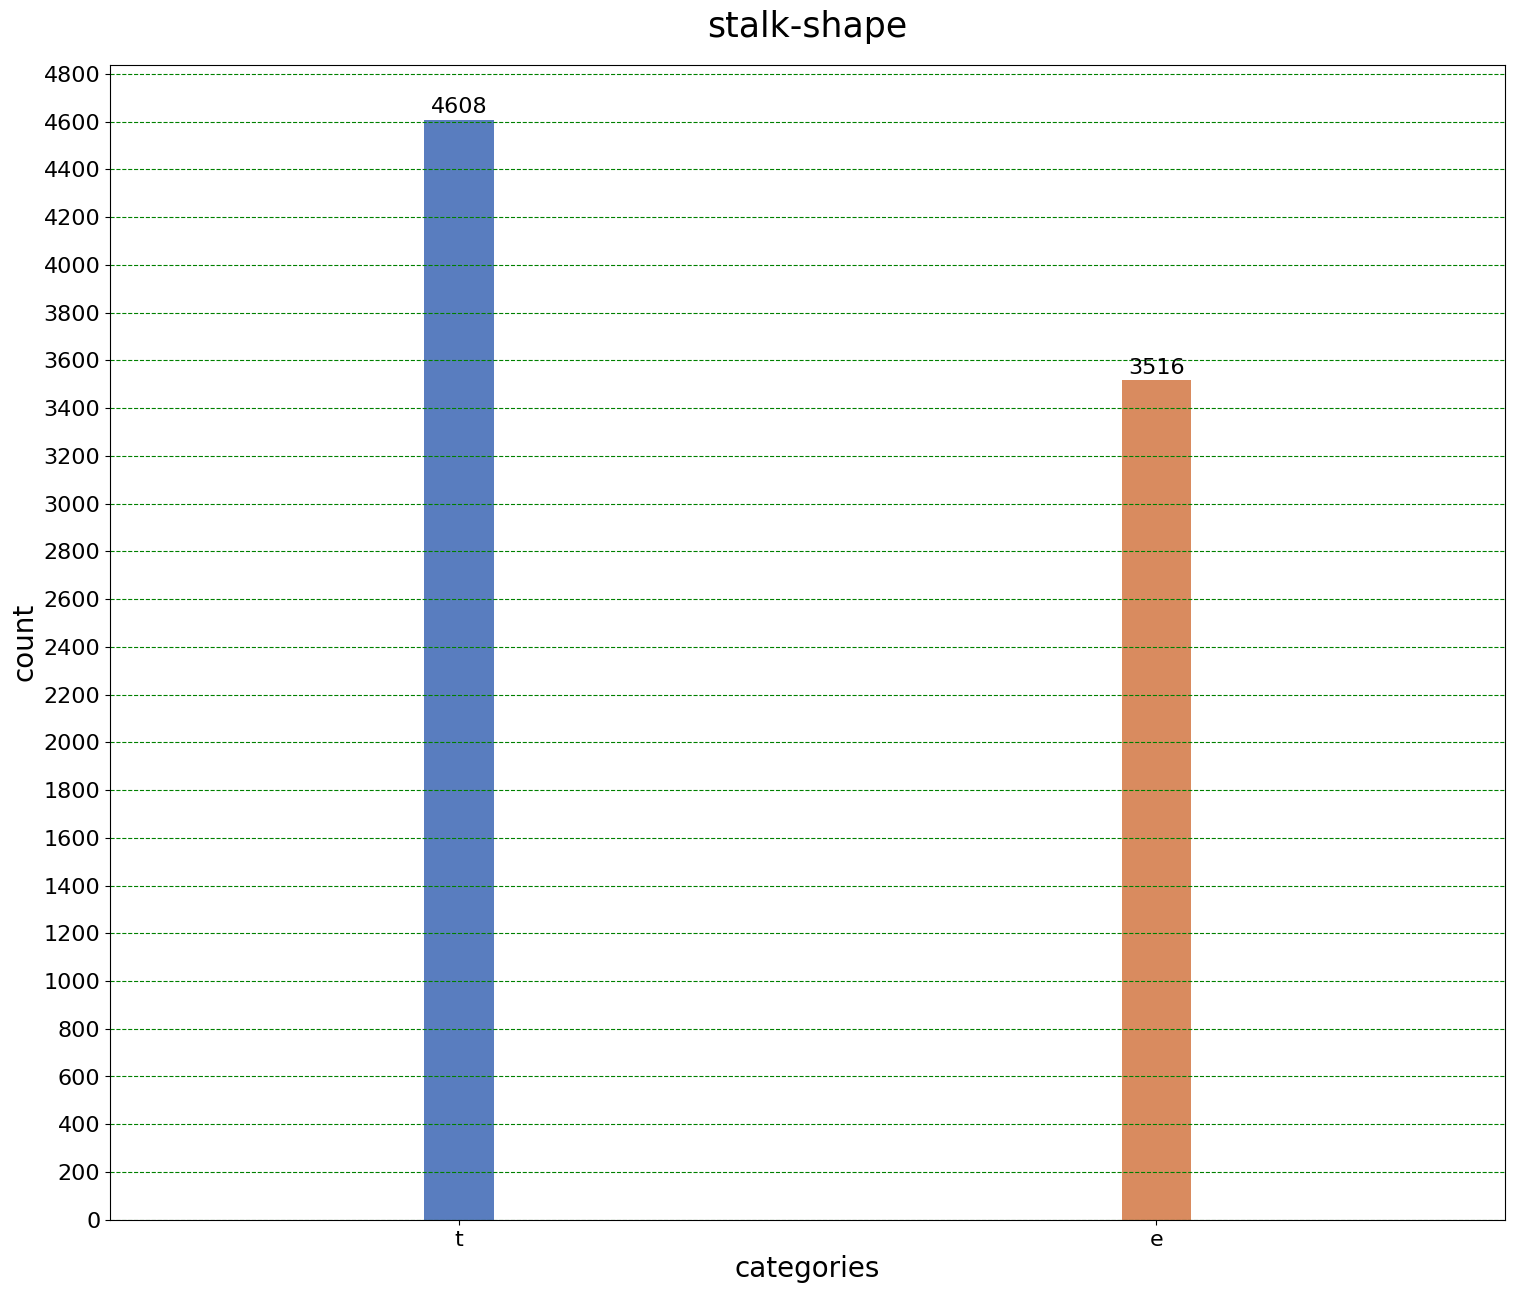

In [226]:
plt.figure(figsize=(18,15))
ax = sns.barplot(x=df['stalk-shape'].value_counts().index,y=df['stalk-shape'].value_counts().values , palette='muted',width=0.1)
plt.title('stalk-shape',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,5000,200),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)


plt.show()


In [227]:
df['gill-color'].value_counts()

gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64

In [228]:
df['gill-size'].value_counts()

gill-size
b    5612
n    2512
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\37360135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gill-size', data=df, palette='bright',width=0.1)


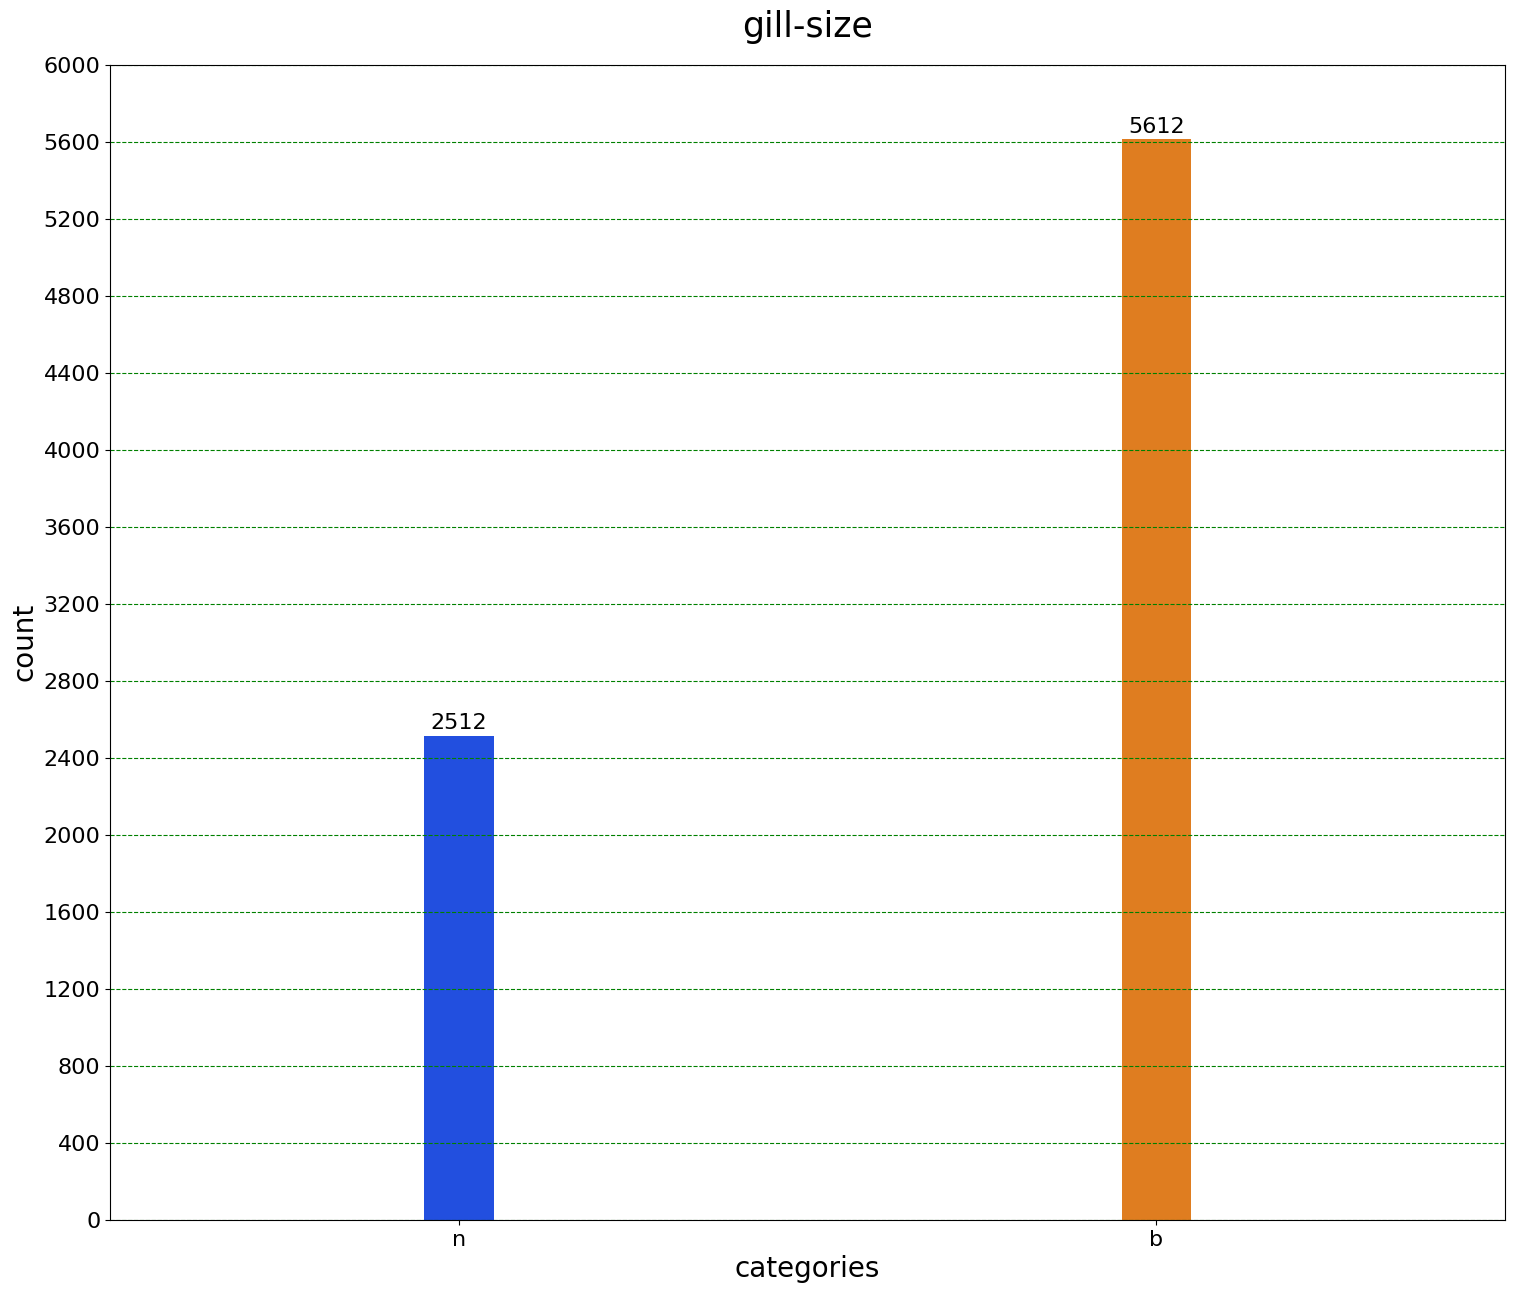

In [229]:
plt.figure(figsize=(18,15))
ax = sns.countplot(x='gill-size', data=df, palette='bright',width=0.1)
plt.title('gill-size',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,6020,400),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)


plt.show()


In [230]:
df['gill-spacing'].value_counts()

gill-spacing
c    6812
w    1312
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\565240966.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gill-spacing', data=df, palette='colorblind',width=0.1)


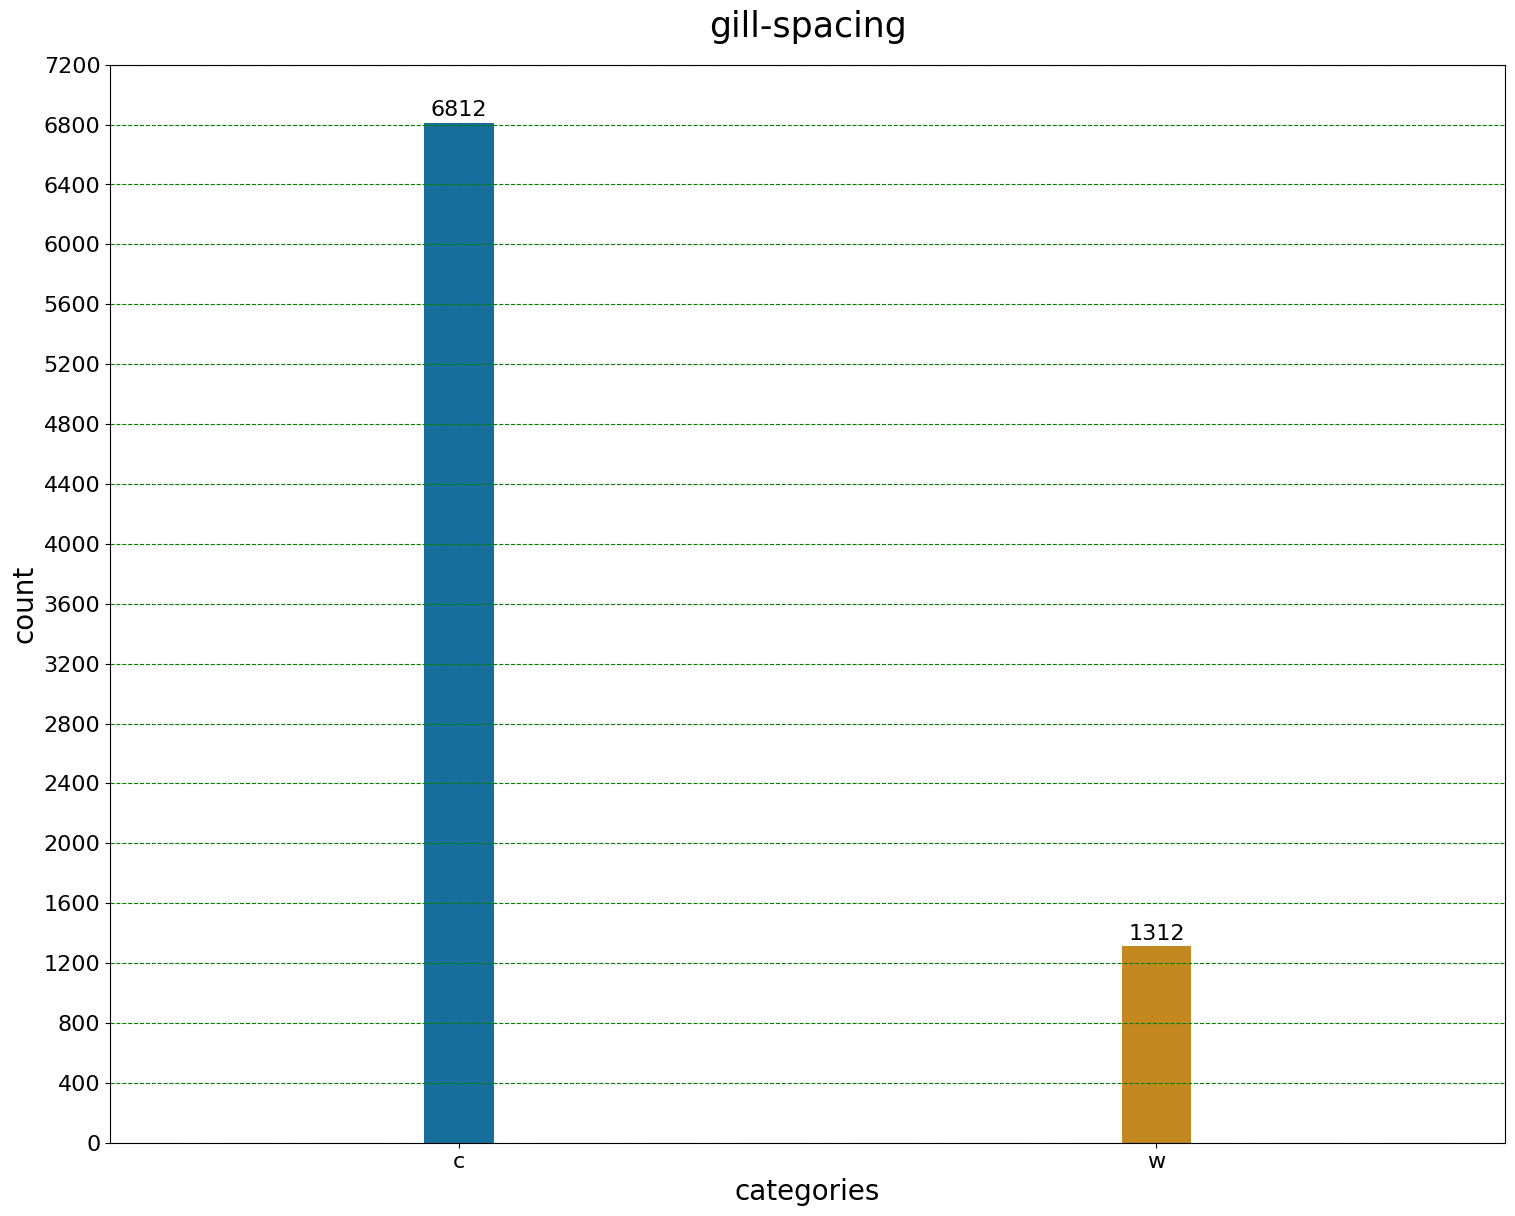

In [231]:
plt.figure(figsize=(18,14))
ax = sns.countplot(x='gill-spacing', data=df, palette='colorblind',width=0.1)
plt.title('gill-spacing',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,7400,400),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)


plt.show()


In [232]:
df['gill-attachment'].value_counts()

gill-attachment
f    7914
a     210
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\2329187278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gill-attachment', data=df, palette='Set2',width=0.1)


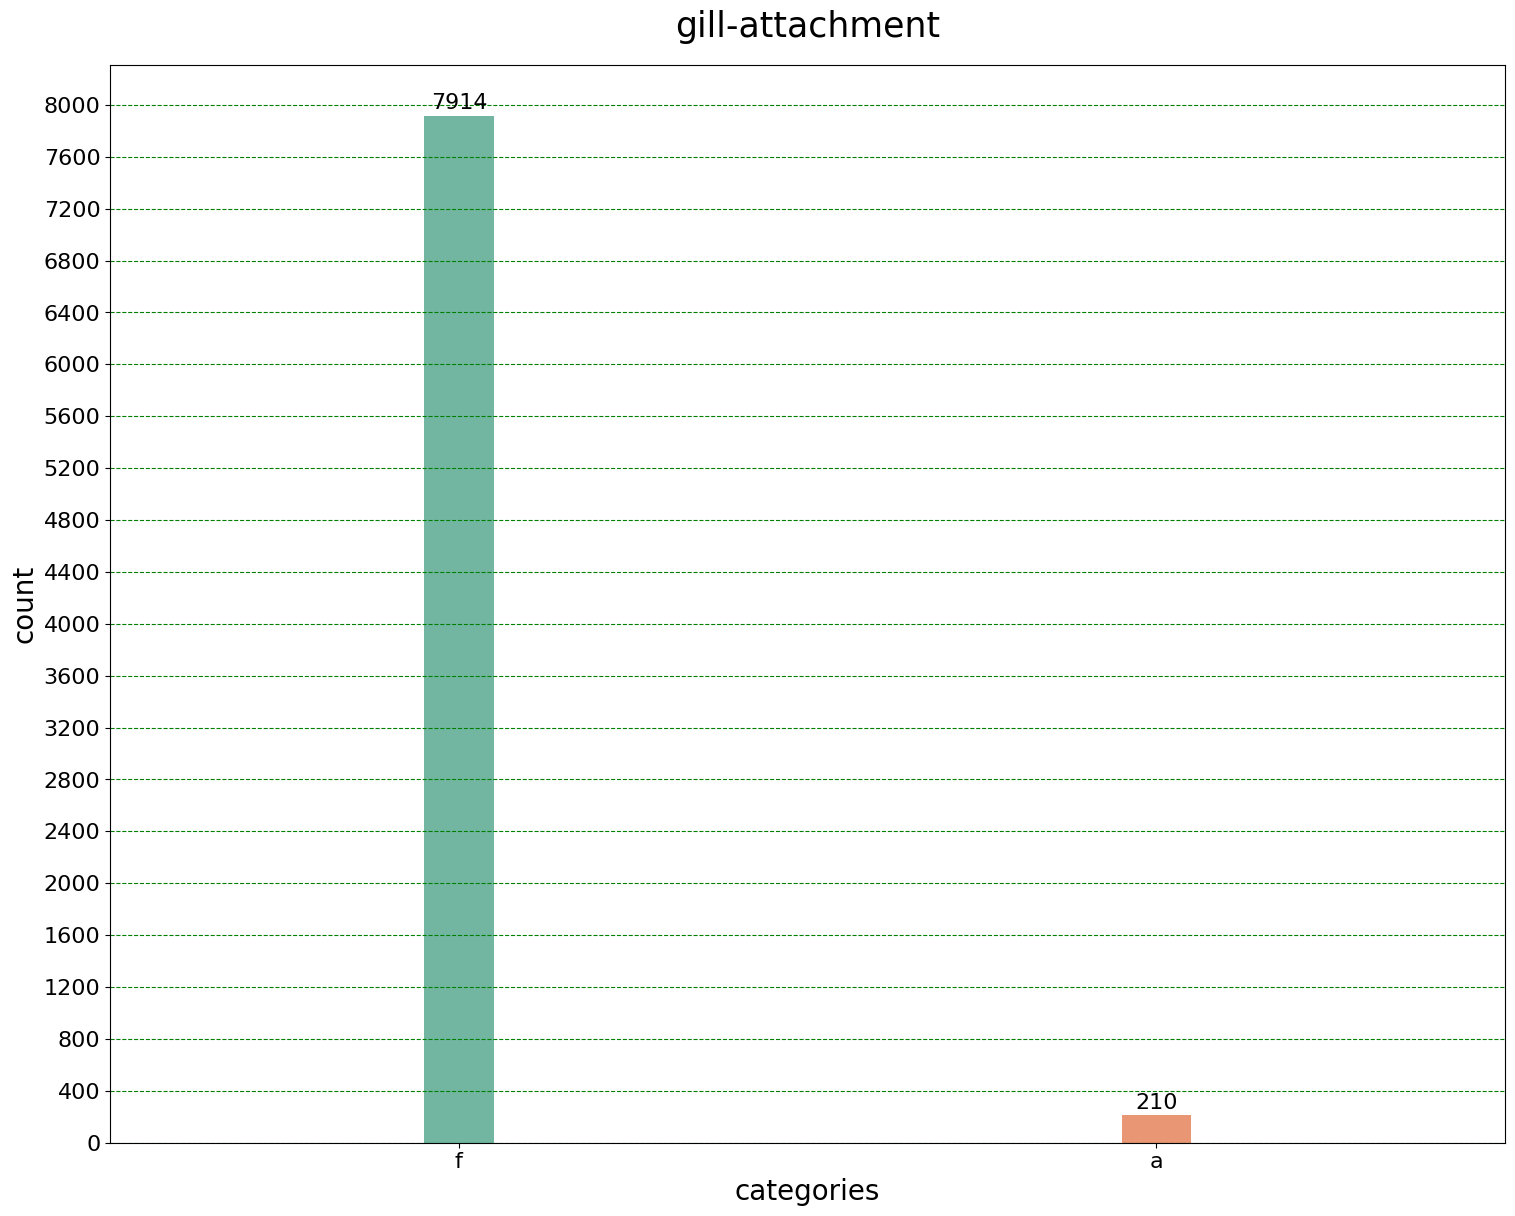

In [233]:
plt.figure(figsize=(18,14))
ax = sns.countplot(x='gill-attachment', data=df, palette='Set2',width=0.1)
plt.title('gill-attachment',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,8100,400),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)
plt.show()


In [234]:
df['odor'].value_counts()

odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

In [235]:
df['bruises'].value_counts()

bruises
f    4748
t    3376
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\161926852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='bruises', data=df, palette='Set1',width=0.1)


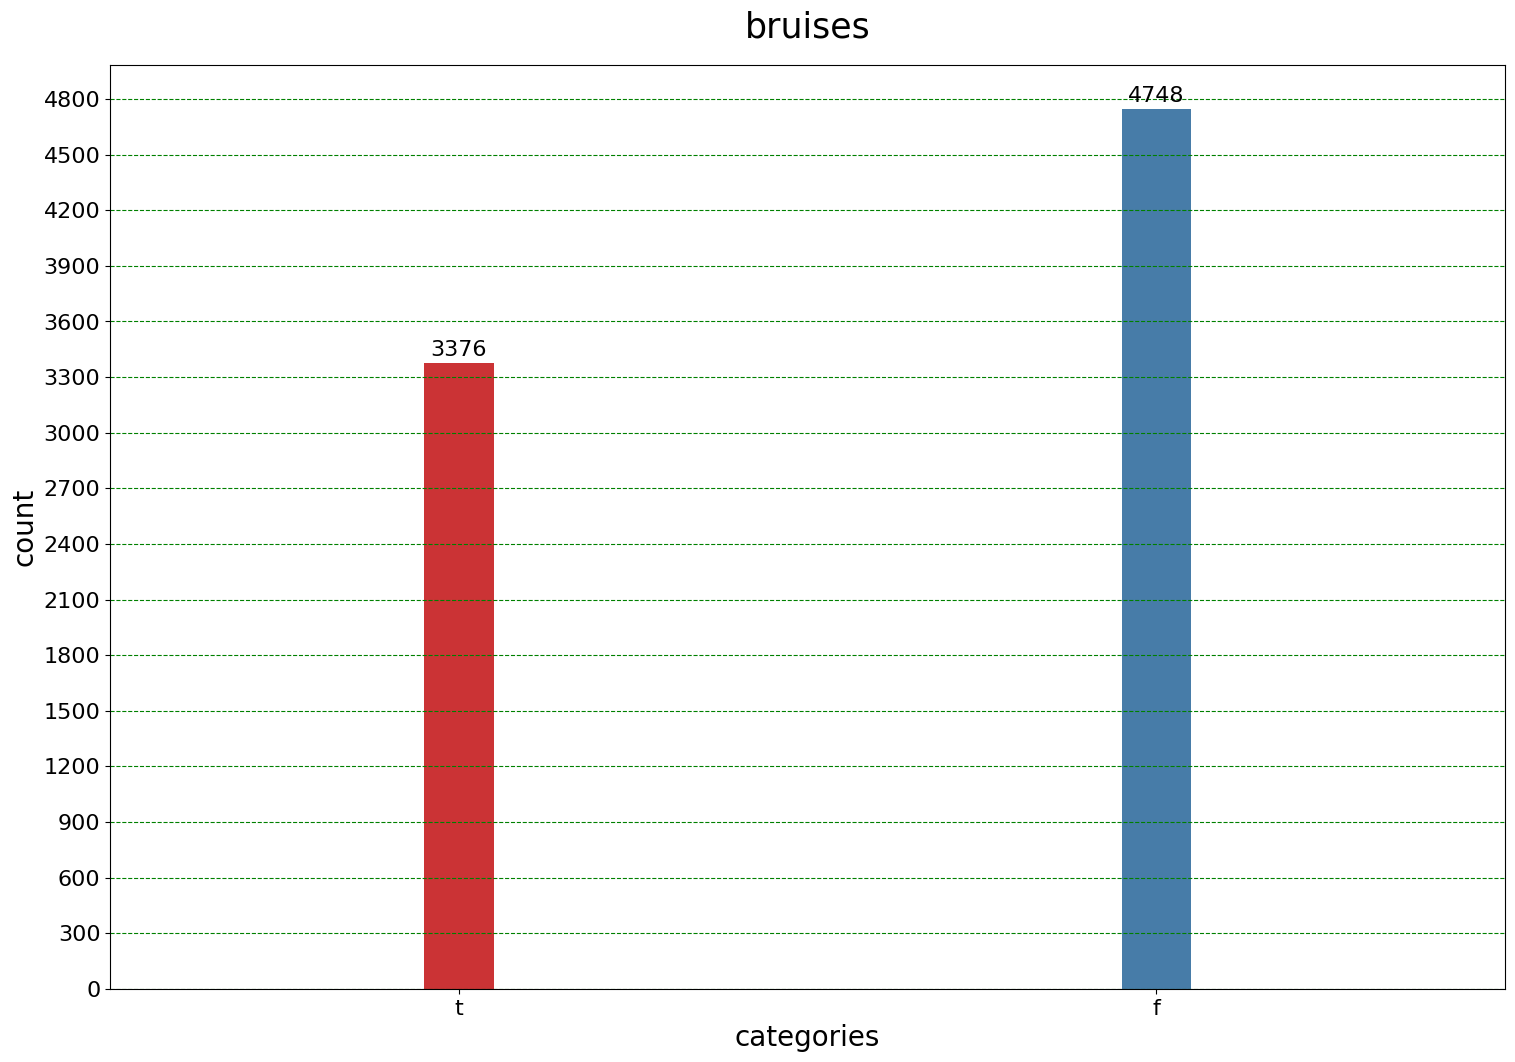

In [236]:
plt.figure(figsize=(18,12))
ax = sns.countplot(x='bruises', data=df, palette='Set1',width=0.1)
plt.title('bruises',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,5000,300),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)
plt.show()


In [237]:
df['cap-color'].value_counts()

cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

In [238]:
df['cap-surface'].value_counts()

cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

In [239]:
df['cap-shape'].value_counts()

cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

In [240]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\802946711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=df, palette='hls',width=0.1)


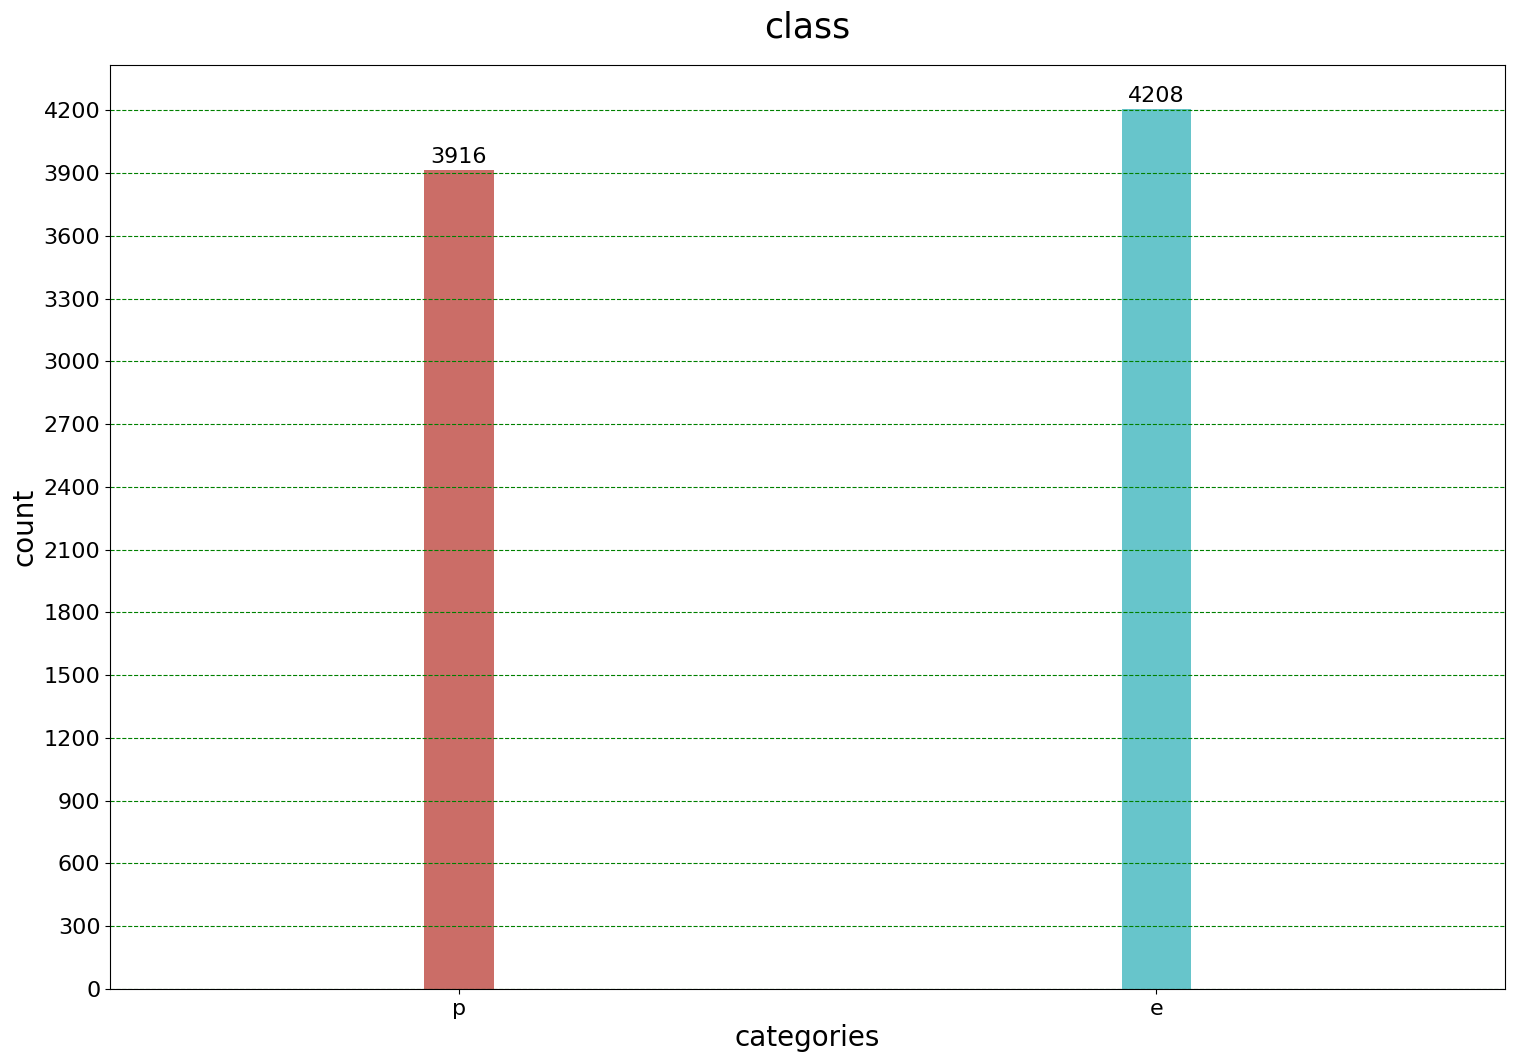

In [241]:
plt.figure(figsize=(18,12))
ax = sns.countplot(x='class', data=df, palette='hls',width=0.1)
plt.title('class',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,4500,300),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)
plt.show()


#### **Bivariate Analysis**

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

# stalk-color-above-ring + stalk-color-below-ring

In [243]:
G=pd.crosstab(df['stalk-color-above-ring'],df['stalk-color-below-ring'])

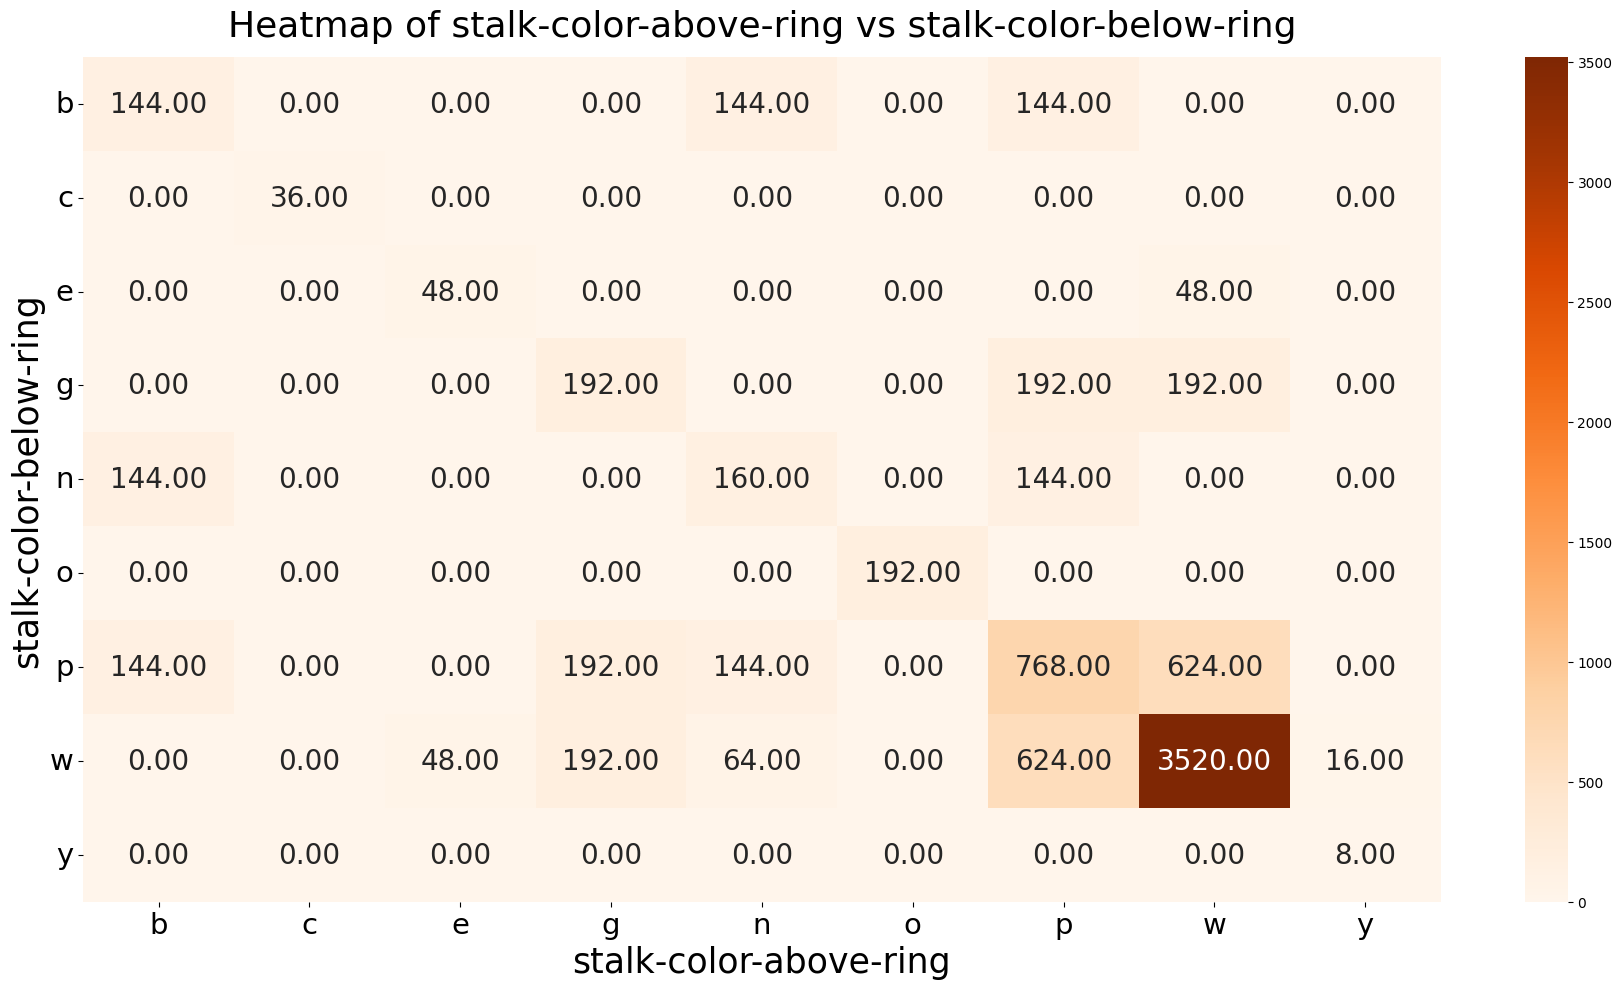

In [244]:
plt.figure(figsize=(18,10))
sns.heatmap(G, annot=True,fmt='.2f', cmap="Oranges",annot_kws={"size": 20}) 
plt.title("Heatmap of stalk-color-above-ring vs stalk-color-below-ring", fontsize=26, pad=15) 
plt.xlabel("stalk-color-above-ring", fontsize=25)
plt.ylabel("stalk-color-below-ring", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# stalk-surface-above-ring + stalk-surface-below-ring

In [245]:
R=pd.crosstab(df['stalk-surface-above-ring'],df['stalk-surface-below-ring'])

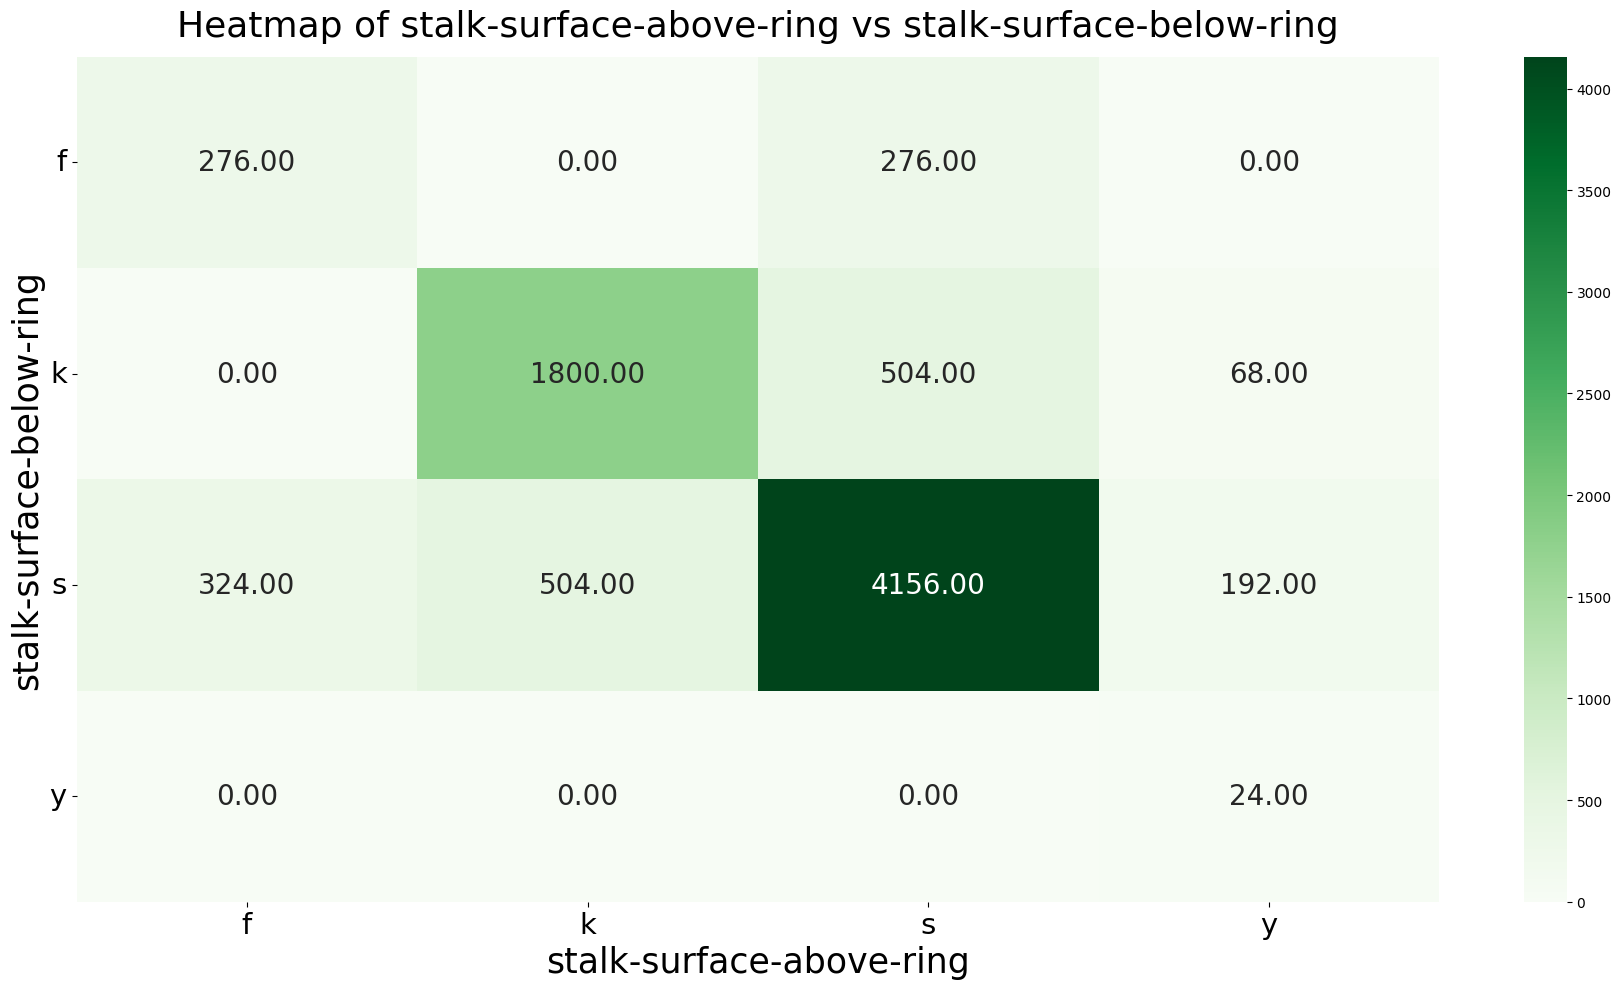

In [246]:
plt.figure(figsize=(18,10))
sns.heatmap(R, annot=True,fmt='.2f', cmap="Greens",annot_kws={"size": 20}) 
plt.title("Heatmap of stalk-surface-above-ring vs stalk-surface-below-ring", fontsize=26, pad=15) 
plt.xlabel("stalk-surface-above-ring", fontsize=25)
plt.ylabel("stalk-surface-below-ring", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# gill-attachment + gill-spacing

In [247]:
S=pd.crosstab(df['gill-attachment'],df['gill-spacing'])

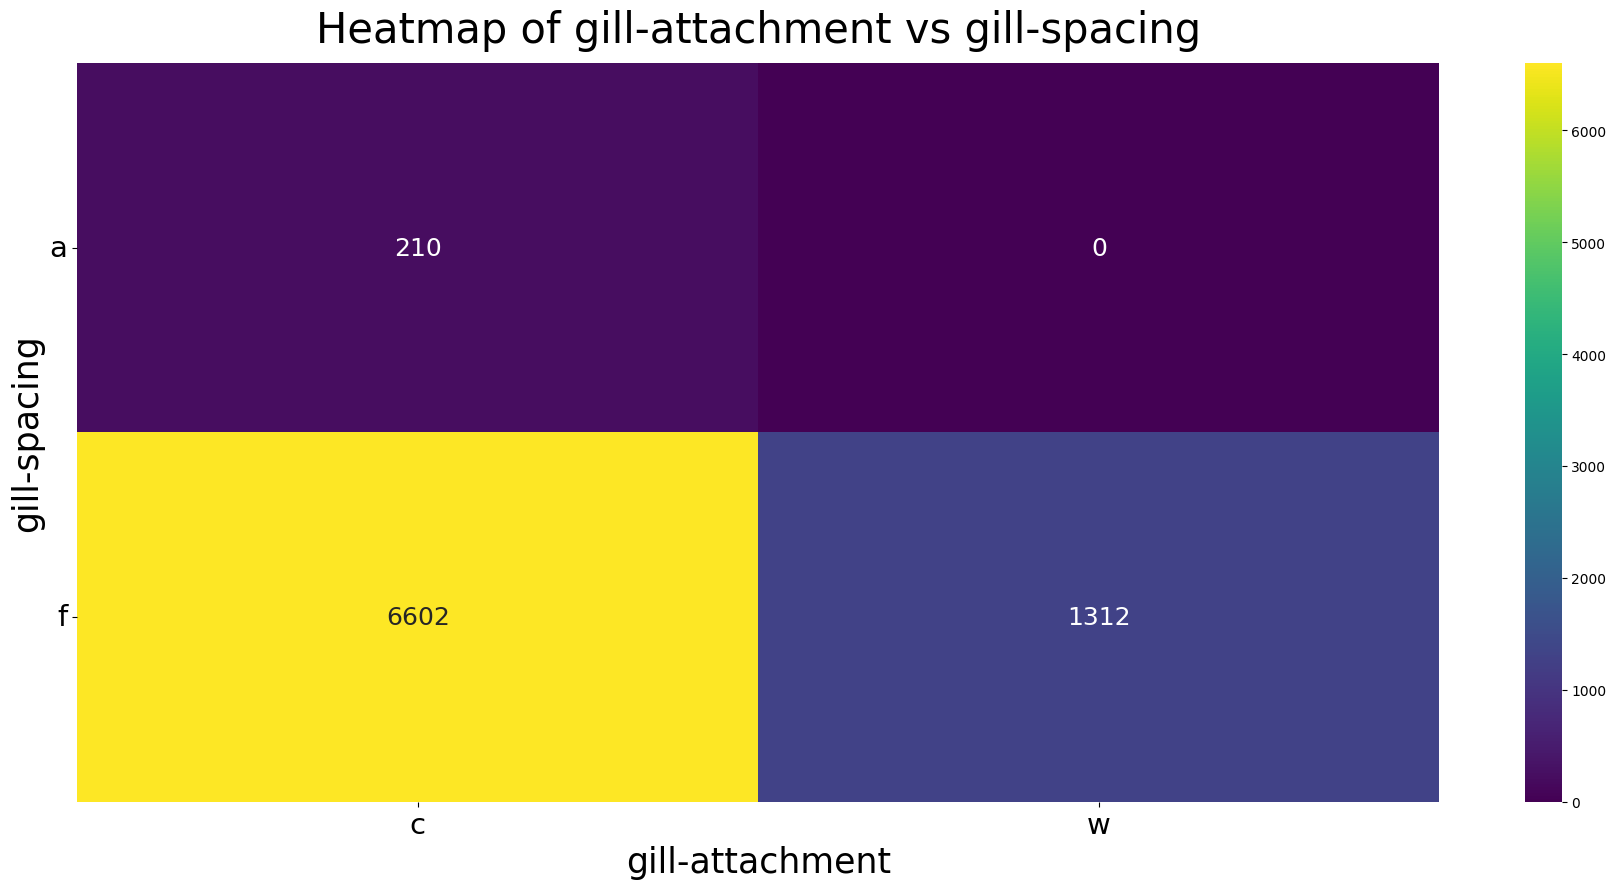

In [248]:
plt.figure(figsize=(18,9))
sns.heatmap(S, annot=True, fmt="d", cmap="viridis",annot_kws={"size": 18}) 
plt.title("Heatmap of gill-attachment vs gill-spacing", fontsize=30, pad=15) 
plt.xlabel("gill-attachment", fontsize=25)
plt.ylabel("gill-spacing", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# cap-shape + cap-surface 

In [249]:
T=pd.crosstab(df['cap-shape'],df['cap-color'])

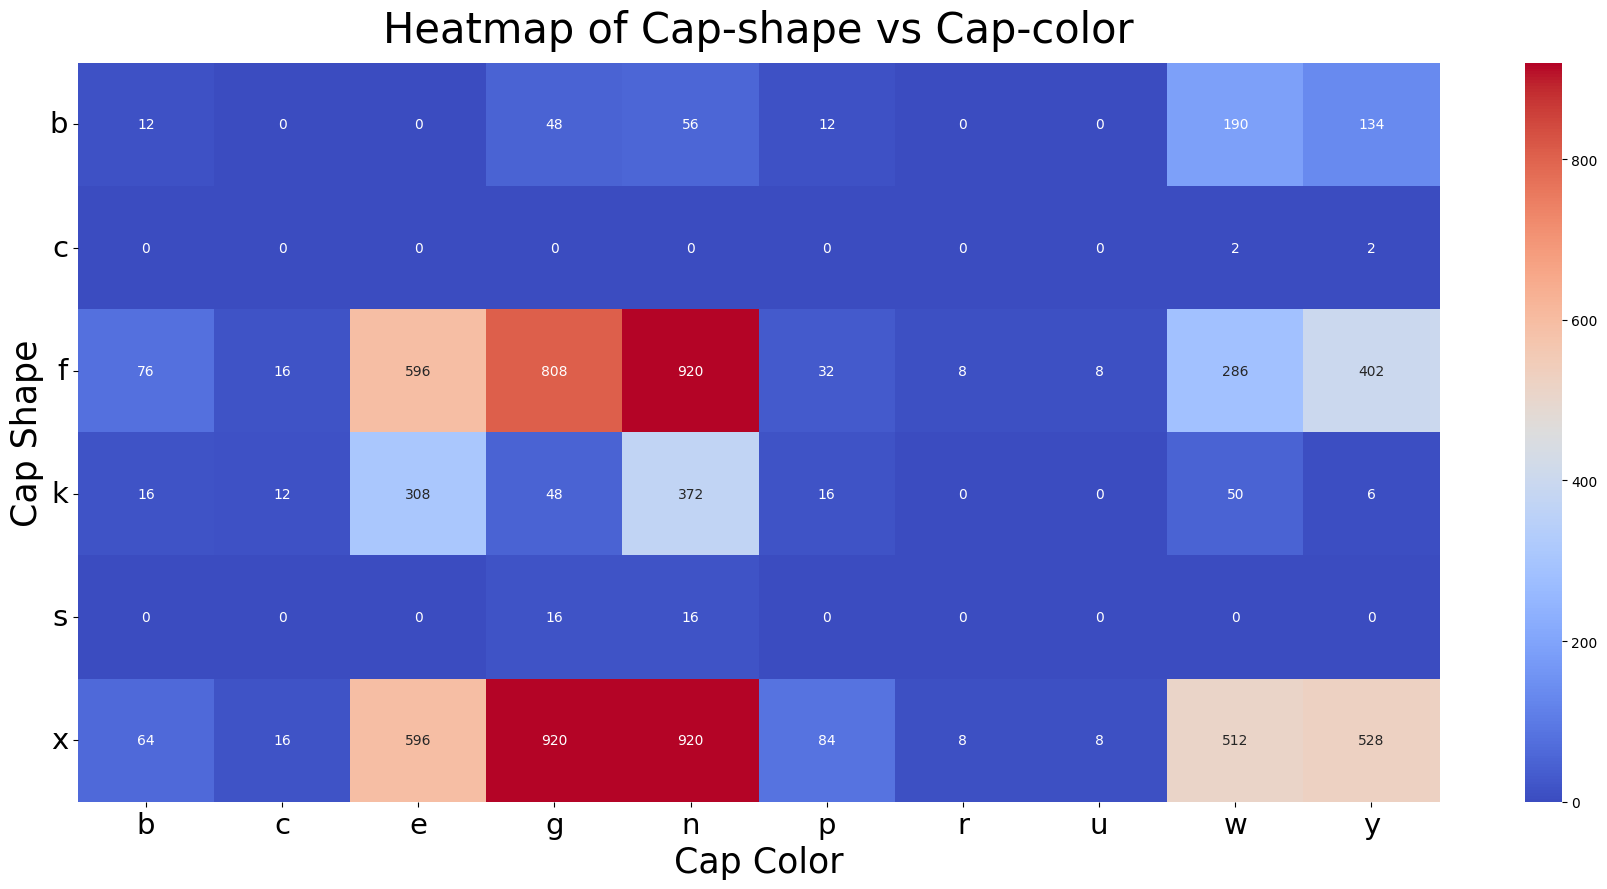

In [250]:
plt.figure(figsize=(18,9))
sns.heatmap(T, annot=True, fmt="d", cmap="coolwarm") 
plt.title("Heatmap of Cap-shape vs Cap-color", fontsize=30, pad=15) 
plt.xlabel("Cap Color", fontsize=25)
plt.ylabel("Cap Shape", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# multivariate analysis

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

# class + population + habitat

In [252]:
pd.crosstab(df['class'],df['population']),df['habitat']

(population    a    c    n    s     v     y
 class                                     
 e           384  288  400  880  1192  1064
 p             0   52    0  368  2848   648,
 0       u
 1       g
 2       m
 3       u
 4       g
        ..
 8119    l
 8120    l
 8121    l
 8122    l
 8123    l
 Name: habitat, Length: 8124, dtype: object)

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\3454271519.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


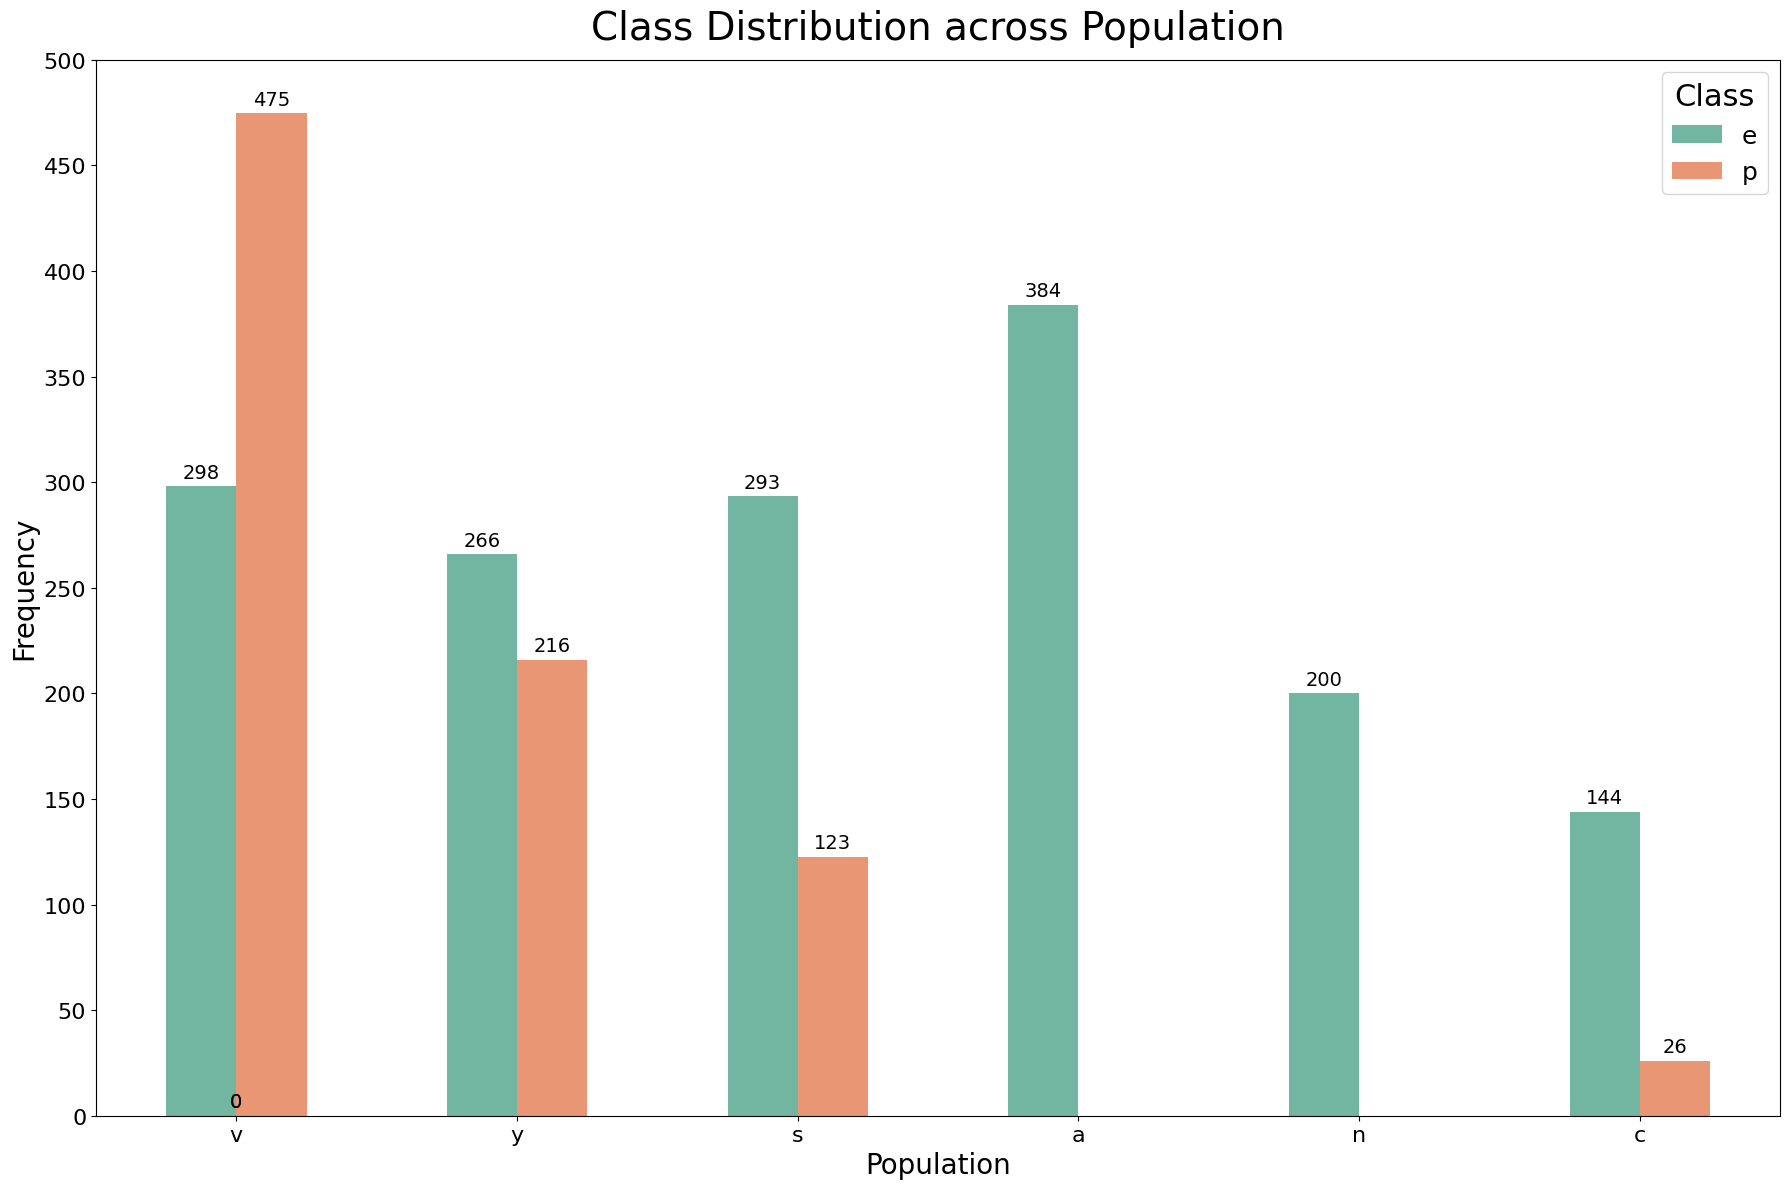

In [253]:
plt.figure(figsize=(18,12))

sns.barplot(
    data=Q.sort_values("count", ascending=False),
    x='population',
    y='count',
    hue='class',
    palette='Set2',
    ci=None,width=0.5)

plt.title("Class Distribution across Population", fontsize=28, pad=15)
plt.xlabel("Population", fontsize=20)
plt.ylabel("Frequency", fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(range(0,550,50), fontsize=16)

for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        fontsize=14, color='black',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.legend(title="Class", title_fontsize=22, fontsize=18, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


#### **Drop Unneeded Columns**

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [255]:
df.drop(columns=['veil-type','veil-color','ring-number','ring-type'],inplace=True)

In [256]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,w,v,l


#### **x and y**

In [257]:
x=df.drop('class',axis=1)
y=df[['class']]

In [258]:
x

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,k,s,u
1,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,n,n,g
2,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,n,n,m
3,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,k,s,u
4,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,w,v,l


In [259]:
y

,class
0,p
1,e
2,e
3,p
4,e
...,...
8119,e
8120,e
8121,e
8122,p


# label encoder

In [260]:
encoder=LabelEncoder()
x['cap-shape']=encoder.fit_transform(x['cap-shape'])
x['cap-surface']=encoder.fit_transform(x['cap-surface'])
x['bruises']=encoder.fit_transform(x['bruises'])
x['odor']=encoder.fit_transform(x['odor'])
x['gill-attachment']=encoder.fit_transform(x['gill-attachment'])
x['gill-spacing']=encoder.fit_transform(x['gill-spacing'])
x['gill-size']=encoder.fit_transform(x['gill-size'])
x['gill-color']=encoder.fit_transform(x['gill-color'])
x['stalk-shape']=encoder.fit_transform(x['stalk-shape'])
x['stalk-root']=encoder.fit_transform(x['stalk-root'])
x['stalk-surface-above-ring']=encoder.fit_transform(x['stalk-surface-above-ring'])
x['stalk-surface-below-ring']=encoder.fit_transform(x['stalk-surface-below-ring'])
x['stalk-color-above-ring']=encoder.fit_transform(x['stalk-color-above-ring'])
x['stalk-color-below-ring']=encoder.fit_transform(x['stalk-color-below-ring'])
x['spore-print-color']=encoder.fit_transform(x['spore-print-color'])
x['population']=encoder.fit_transform(x['population'])
x['habitat']=encoder.fit_transform(x['habitat'])
x['cap-color']=encoder.fit_transform(x['cap-color'])


In [261]:
encoder=LabelEncoder()
y['class']=encoder.fit_transform(y['class'])

C:\Users\Mega\AppData\Local\Temp\ipykernel_22908\3523760848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class']=encoder.fit_transform(y['class'])


In [262]:
x

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,3,2,2,7,7,2,3,5
1,5,2,9,1,0,1,0,0,4,0,2,2,2,7,7,3,2,1
2,0,2,8,1,3,1,0,0,5,0,2,2,2,7,7,3,2,3
3,5,3,8,1,6,1,0,1,5,0,3,2,2,7,7,2,3,5
4,5,2,3,0,5,1,1,0,4,1,3,2,2,7,7,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,3,2,4,0,5,0,0,0,11,0,0,2,2,5,5,0,1,2
8120,5,2,4,0,5,0,0,0,11,0,0,2,2,5,5,0,4,2
8121,2,2,4,0,5,0,0,0,5,0,0,2,2,5,5,0,1,2
8122,3,3,4,0,8,1,0,1,0,1,0,2,1,7,7,7,4,2


In [263]:
y

,class
0,1
1,0
2,0
3,1
4,0
...,...
8119,0
8120,0
8121,0
8122,1


# train_test_split

In [264]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=48,test_size=0.2)

# LogisticRegression

In [271]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [272]:
lr.score(x_train,y_train)

0.9418372057239576

In [273]:
lr.score(x_test,y_test)

0.9421538461538461

In [274]:
y_pred=lr.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      3464
           1       0.93      0.95      0.94      3035

    accuracy                           0.94      6499
   macro avg       0.94      0.94      0.94      6499
weighted avg       0.94      0.94      0.94      6499



In [275]:
y_pred=lr.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       858
           1       0.92      0.96      0.94       767

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625



# svc

In [276]:
svm=SVC()
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [277]:
svm.score(x_train,y_train)

0.9915371595630097

In [278]:
svm.score(x_test,y_test)

0.9883076923076923

In [279]:
y_pred=svm.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3429
           1       0.98      1.00      0.99      3070

    accuracy                           0.99      6499
   macro avg       0.99      0.99      0.99      6499
weighted avg       0.99      0.99      0.99      6499



In [280]:
y_pred=svm.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       845
           1       0.98      1.00      0.99       780

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



# DecisionTreeClassifier


In [282]:

tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [283]:
tree.score(x_train,y_train)

1.0

In [284]:
tree.score(x_test,y_test)

1.0

In [285]:
y_pred=tree.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [286]:
y_pred=tree.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



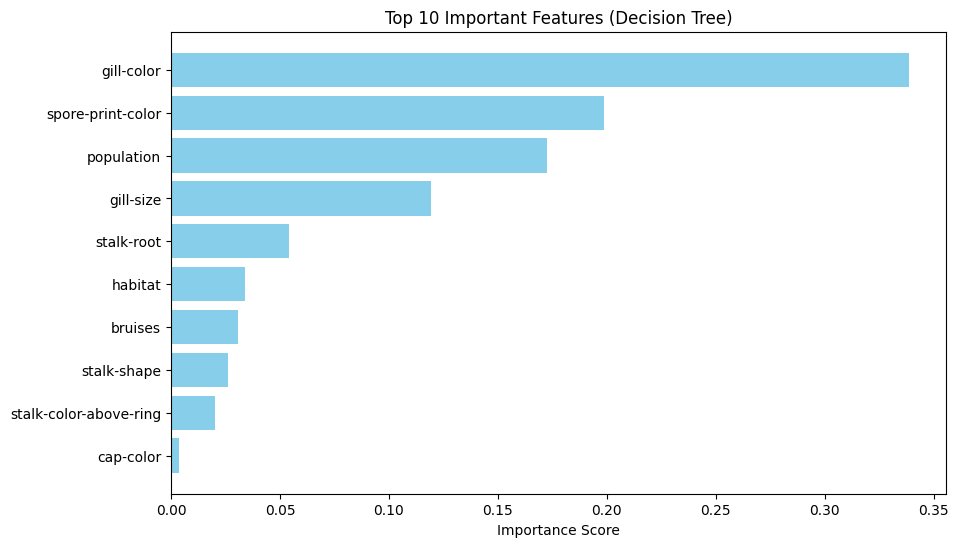

                   Feature  Importance
8               gill-color    0.338660
15       spore-print-color    0.198700
16              population    0.172625
7                gill-size    0.119215
10              stalk-root    0.054039
17                 habitat    0.034078
3                  bruises    0.030559
9              stalk-shape    0.026005
13  stalk-color-above-ring    0.020182
2                cap-color    0.003765


In [287]:


# 1. استخراج الأهمية
importances = tree.feature_importances_
feature_names = x_train.columns # تأكد أن x_train هو DataFrame

# 2. تنظيمهم في جدول
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. رسم بياني لأول 10 أعمدة
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

# طباعة القيم
print(feature_importance_df.head(10))

# KNeighborsClassifier

In [290]:
neighbors=KNeighborsClassifier(n_neighbors=1)
neighbors.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [291]:
neighbors.score(x_train,y_train)

1.0

In [292]:
neighbors.score(x_test,y_test)

1.0

In [293]:
y_pred=neighbors.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [294]:
y_pred=neighbors.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier

In [295]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [296]:
rf.score(x_train,y_train)

1.0

In [297]:
rf.score(x_test,y_test)

1.0

In [298]:
y_pred=rf.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [299]:
y_pred=rf.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [300]:
ext=ExtraTreesClassifier()
ext.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [301]:
ext.score(x_train,y_train)

1.0

In [302]:
ext.score(x_test,y_test)

1.0

In [303]:
y_pred=ext.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [304]:
y_pred=ext.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [305]:
bag=BaggingClassifier()
bag.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [306]:
bag.score(x_train,y_train)

1.0

In [307]:
bag.score(x_test,y_test)

1.0

In [308]:
y_pred=bag.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [309]:
y_pred=bag.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [314]:
ada=AdaBoostClassifier(n_estimators=100)
ada.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [315]:
ada.score(x_train,y_train)

0.9989229112171103

In [316]:
ada.score(x_test,y_test)

0.9993846153846154

In [317]:
y_pred=ada.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3385
           1       1.00      1.00      1.00      3114

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [318]:
y_pred=ada.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       831
           1       1.00      1.00      1.00       794

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [319]:
vot=VotingClassifier(estimators=[('t1',KNeighborsClassifier()),
                                 ('t2',DecisionTreeClassifier()),
                                 ('t3',LogisticRegression()),
                                 ('t4',SVC())])
vot.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sc

,estimators,"[('t1', ...), ('t2', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [320]:
vot.score(x_train,y_train)

0.992152638867518

In [321]:
vot.score(x_test,y_test)

0.9895384615384616

In [322]:
y_pred=vot.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3429
           1       0.98      1.00      0.99      3070

    accuracy                           0.99      6499
   macro avg       0.99      0.99      0.99      6499
weighted avg       0.99      0.99      0.99      6499



In [323]:
y_pred=vot.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       847
           1       0.98      1.00      0.99       778

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



# xgboost

In [324]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [325]:
xgb.score(x_train,y_train)

1.0

In [326]:
xgb.score(x_test,y_test)

1.0

In [327]:
y_pred=xgb.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [328]:
y_pred=xgb.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# catboost

In [329]:
cat=CatBoostClassifier()
cat.fit(x_train,y_train)

Learning rate set to 0.02291
0:	learn: 0.6427235	total: 148ms	remaining: 2m 28s
1:	learn: 0.6058248	total: 153ms	remaining: 1m 16s
2:	learn: 0.5440046	total: 157ms	remaining: 52.2s
3:	learn: 0.4997597	total: 162ms	remaining: 40.2s
4:	learn: 0.4502385	total: 167ms	remaining: 33.2s
5:	learn: 0.4110860	total: 171ms	remaining: 28.3s
6:	learn: 0.3794263	total: 174ms	remaining: 24.7s
7:	learn: 0.3432784	total: 177ms	remaining: 22s
8:	learn: 0.3161297	total: 182ms	remaining: 20.1s
9:	learn: 0.2864374	total: 190ms	remaining: 18.8s
10:	learn: 0.2648040	total: 193ms	remaining: 17.3s
11:	learn: 0.2403059	total: 198ms	remaining: 16.3s
12:	learn: 0.2144139	total: 207ms	remaining: 15.7s
13:	learn: 0.1974140	total: 213ms	remaining: 15s
14:	learn: 0.1794538	total: 223ms	remaining: 14.6s
15:	learn: 0.1667598	total: 228ms	remaining: 14s
16:	learn: 0.1515805	total: 235ms	remaining: 13.6s
17:	learn: 0.1411422	total: 244ms	remaining: 13.3s
18:	learn: 0.1321681	total: 251ms	remaining: 13s
19:	learn: 0.12410

In [330]:
cat.score(x_train,y_train)

np.float64(1.0)

In [331]:
cat.score(x_test,y_test)

np.float64(1.0)

In [332]:
y_pred=cat.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [333]:
y_pred=cat.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# lightgmb

In [334]:
light=LGBMClassifier()
light.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of

[LightGBM] [Info] Number of positive: 3121, number of negative: 3378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 6499, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.480228 -> initscore=-0.079130
[LightGBM] [Info] Start training from score -0.079130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [335]:
light.score(x_train,y_train)

1.0

In [336]:
light.score(x_test,y_test)

1.0

In [337]:
y_pred=light.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00      3121

    accuracy                           1.00      6499
   macro avg       1.00      1.00      1.00      6499
weighted avg       1.00      1.00      1.00      6499



In [338]:
y_pred=light.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       795

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# naive_bayes

In [339]:
nb=GaussianNB()
nb.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


In [340]:
nb.score(x_train,y_train)

0.9215263886751808

In [341]:
nb.score(x_test,y_test)

0.9335384615384615

In [342]:
y_pred=nb.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      3630
           1       0.88      0.96      0.91      2869

    accuracy                           0.92      6499
   macro avg       0.92      0.93      0.92      6499
weighted avg       0.92      0.92      0.92      6499



In [343]:
y_pred=nb.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       886
           1       0.90      0.96      0.93       739

    accuracy                           0.93      1625
   macro avg       0.93      0.94      0.93      1625
weighted avg       0.94      0.93      0.93      1625



# DEEP LEARNING

In [344]:
x_train.shape

(6499, 18)

In [345]:
y

,class
0,1
1,0
2,0
3,1
4,0
...,...
8119,0
8120,0
8121,0
8122,1


In [346]:


model = Sequential([
    Dense(128, activation='relu', input_dim=18),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax') 
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [347]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,450 (52.54 KB)

 Trainable params: 13,450 (52.54 KB)

 Non-trainable params: 0 (0.00 B)

In [348]:
earlystop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=6,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [349]:
model.fit(x_train, y_train, epochs=70,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/70
128/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7648 - loss: 0.4764

143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8560 - loss: 0.3361 - val_accuracy: 0.9328 - val_loss: 0.1962 - learning_rate: 0.0010
Epoch 2/70
141/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9464 - loss: 0.1438

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9582 - loss: 0.1162 - val_accuracy: 0.9456 - val_loss: 0.1314 - learning_rate: 0.0010
Epoch 3/70
141/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9818 - loss: 0.0556

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - loss: 0.0406 - val_accuracy: 0.9933 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 4/70
135/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9932 - loss: 0.0183

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9936 - loss: 0.0202 - val_accuracy: 0.9887 - val_loss: 0.0321 - learning_rate: 0.0010
Epoch 5/70
129/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.0137

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9965 - loss: 0.0115 - val_accuracy: 0.9949 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 6/70
134/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9933 - loss: 0.0163

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9959 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 7/70
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0045

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9990 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 8/70
126/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0019  

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.0142 - val_accuracy: 0.9954 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 9/70
129/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0151

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9995 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 10/70
135/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.5390e-04

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 5.3481e-04 - val_accuracy: 0.9990 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 11/70
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.4499e-04

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.2441e-04 - val_accuracy: 1.0000 - val_loss: 9.0902e-04 - learning_rate: 0.0010
Epoch 12/70
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.5622e-04

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.5142e-04 - val_accuracy: 1.0000 - val_loss: 8.4479e-04 - learning_rate: 0.0010
Epoch 13/70
136/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.1304e-04

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.1406e-04 - val_accuracy: 1.0000 - val_loss: 7.9040e-04 - learning_rate: 0.0010
Epoch 14/70
141/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.9251e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 8.8498e-05 - val_accuracy: 1.0000 - val_loss: 7.1798e-04 - learning_rate: 0.0010
Epoch 15/70
136/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.2680e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.2914e-05 - val_accuracy: 1.0000 - val_loss: 6.4117e-04 - learning_rate: 0.0010
Epoch 16/70
124/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.3915e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 6.0355e-05 - val_accuracy: 1.0000 - val_loss: 5.7506e-04 - learning_rate: 0.0010
Epoch 17/70
117/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.0062e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 5.1516e-05 - val_accuracy: 1.0000 - val_loss: 4.8970e-04 - learning_rate: 0.0010
Epoch 18/70
119/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.8776e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 4.4738e-05 - val_accuracy: 1.0000 - val_loss: 4.5898e-04 - learning_rate: 0.0010
Epoch 19/70
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.3176e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.8147e-05 - val_accuracy: 1.0000 - val_loss: 4.4231e-04 - learning_rate: 0.0010
Epoch 20/70
135/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.4544e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.4357e-05 - val_accuracy: 1.0000 - val_loss: 4.1427e-04 - learning_rate: 0.0010
Epoch 21/70
134/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.7068e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.0287e-05 - val_accuracy: 1.0000 - val_loss: 3.8309e-04 - learning_rate: 0.0010
Epoch 22/70
121/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.2581e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.6393e-05 - val_accuracy: 1.0000 - val_loss: 3.4101e-04 - learning_rate: 0.0010
Epoch 23/70
127/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.3567e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.3108e-05 - val_accuracy: 1.0000 - val_loss: 3.2026e-04 - learning_rate: 0.0010
Epoch 24/70
134/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.5238e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.1630e-05 - val_accuracy: 1.0000 - val_loss: 2.8824e-04 - learning_rate: 0.0010
Epoch 25/70
133/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.8522e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.8489e-05 - val_accuracy: 1.0000 - val_loss: 2.6117e-04 - learning_rate: 0.0010
Epoch 26/70
118/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.4812e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.6192e-05 - val_accuracy: 1.0000 - val_loss: 2.4158e-04 - learning_rate: 0.0010
Epoch 27/70
129/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.5302e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.4656e-05 - val_accuracy: 1.0000 - val_loss: 2.4272e-04 - learning_rate: 0.0010
Epoch 28/70
137/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.1703e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.3010e-05 - val_accuracy: 1.0000 - val_loss: 2.3036e-04 - learning_rate: 0.0010
Epoch 29/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.1405e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.1921e-05 - val_accuracy: 1.0000 - val_loss: 2.0531e-04 - learning_rate: 0.0010
Epoch 30/70
126/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.0368e-05

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.0649e-05 - val_accuracy: 1.0000 - val_loss: 1.9319e-04 - learning_rate: 0.0010
Epoch 31/70
125/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 8.8186e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 9.7492e-06 - val_accuracy: 1.0000 - val_loss: 1.7682e-04 - learning_rate: 0.0010
Epoch 32/70
129/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.0003e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 9.0239e-06 - val_accuracy: 1.0000 - val_loss: 1.7502e-04 - learning_rate: 1.0000e-04
Epoch 33/70
127/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.0359e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 8.7813e-06 - val_accuracy: 1.0000 - val_loss: 1.7673e-04 - learning_rate: 1.0000e-04
Epoch 34/70
120/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 8.1829e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.6419e-06 - val_accuracy: 1.0000 - val_loss: 1.7761e-04 - learning_rate: 1.0000e-04
Epoch 35/70
134/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.1904e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.5396e-06 - val_accuracy: 1.0000 - val_loss: 1.7791e-04 - learning_rate: 1.0000e-04
Epoch 36/70
131/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.7482e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.4503e-06 - val_accuracy: 1.0000 - val_loss: 1.7679e-04 - learning_rate: 1.0000e-04
Epoch 37/70
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.5378e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.3475e-06 - val_accuracy: 1.0000 - val_loss: 1.7513e-04 - learning_rate: 1.0000e-04
Epoch 38/70
131/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.4465e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.2231e-06 - val_accuracy: 1.0000 - val_loss: 1.7521e-04 - learning_rate: 1.0000e-05
Epoch 39/70
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.2068e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.2114e-06 - val_accuracy: 1.0000 - val_loss: 1.7533e-04 - learning_rate: 1.0000e-05
Epoch 40/70
133/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.0708e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.1992e-06 - val_accuracy: 1.0000 - val_loss: 1.7505e-04 - learning_rate: 1.0000e-05
Epoch 41/70
127/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.6564e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 8.1845e-06 - val_accuracy: 1.0000 - val_loss: 1.7511e-04 - learning_rate: 1.0000e-05
Epoch 42/70
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.4341e-06

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 8.1744e-06 - val_accuracy: 1.0000 - val_loss: 1.7508e-04 - learning_rate: 1.0000e-05


In [350]:
model.evaluate(x_train,y_train)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.8688e-05


[5.8688408898888156e-05, 1.0]

In [351]:
model.evaluate(x_test,y_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.9900e-04


[0.000298998667858541, 1.0]

In [ ]:
import joblib

# افترضنا إن اسم الموديل عندك هو rf
joblib.dump(rf, 'final_mushroom_model.pkl')
print("تم حفظ الموديل بنجاح باسم final_mushroom_model.pkl")

تم حفظ الموديل بنجاح باسم final_mushroom_model.pkl


In [ ]:
import streamlit as st
import joblib # أو tensorflow لو هتستخدم الـ Neural Network

# 1. تحميل الموديل (تأكد من وجود ملف الموديل في نفس الفولدر)
model = joblib.load('final_mushroom_model.pkl') 

st.set_page_config(page_title="Mushroom Classifier", page_icon="🍄")

st.title("🍄 Mushroom Edibility Predictor")
st.write("ادخل مواصفات الفطر وهقولك هل هو سام أم صالح للأكل")

# 2. إنشاء الحقول بناءً على الـ 18 عمود اللي عندك
# ملاحظة: استبدل الأسماء بأسماء الأعمدة الحقيقية من x_train.columns
st.sidebar.header("Mushroom Features")

def user_input_features():
    gill_color = st.sidebar.slider('Gill Color (coded)', 0, 12, 5)
    spore_print = st.sidebar.slider('Spore Print Color', 0, 8, 4)
    population = st.sidebar.slider('Population', 0, 5, 2)
    # ... كرر لبقية الـ 18 عمود ...
    
    data = {
        'gill-color': gill_color,
        'spore-print-color': spore_print,
        'population': population,
        # أضف الباقي هنا
    }
    return pd.DataFrame(data, index=[0])

df = user_input_features()

# 3. التوقع
if st.button('Predict'):
    prediction = model.predict(df)
    
    if prediction[0] == 1:
        st.error("🚨 Warning: This mushroom is POISONOUS!")
    else:
        st.success("✅ Safe: This mushroom is EDIBLE.")

st.write("Feature Importance Summary:")
st.bar_chart(df.T) # رسم بياني سريع للمدخلات

2026-01-30 03:33:08.677 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-30 03:33:08.678 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-30 03:33:09.088 
  command:

    streamlit run C:\Users\Mega\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-30 03:33:09.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-30 03:33:09.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-30 03:33:09.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-30 03:33:09.090 Thread 'MainThread': missing ScriptRunContext! This warning can be

DeltaGenerator()